## Deep Neural Network Model (version 2) with selected features


This notebook is a version 2 of the selected-features DNN workflow. It keeps the same data source and selected feature idea, but changes the modeling pipeline so categorical embeddings are trainable inside the Keras model rather than precomputed as random dataframe columns.

Main changes from version 1:

- Numeric features are log-transformed and scaled, with extra binary indicators for zero-heavy count features.
- Categorical features are passed to the model as raw string inputs.
- Each categorical feature has its own `StringLookup` and trainable `Embedding` layer.
- Numeric features and categorical embeddings are concatenated inside the Keras graph.
- Optuna optimizes `val_pr_auc` with a bounded learning-rate search.
- The final classification threshold is selected on the validation set instead of assuming `0.5`.


### Part 1

####  1.1 Importing the necessary libraries and constant variables


If using google colab, use the following code:


In [1]:
run_in_colab = False

In [2]:
def if_colab_run_this():
    import os
    # Clone the repo into Colab's working directory
    !git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

    # Install optuna in google colab
    !pip install optuna

    # Add project root to Python path so 'src' is importable
    import sys
    sys.path.insert(0, '/content/ds207_final_project')
    # Verify src exists
    from pathlib import Path
    src_path = Path('/content/ds207_final_project/src')
    print(f"src exists: {src_path.exists()}")
    print("src contents:")
    for item in sorted(src_path.iterdir()):
        print(f"  {item.name}")

# apply the function only if you run it in google colab:
if run_in_colab:
    if_colab_run_this()

In [3]:

import os
import tempfile
from pathlib import Path

# custom imports
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix

# for implementing neural network
import tensorflow as tf
from tensorflow import keras
import random
import re

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for data preprocessing
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score)

# for hyperparameter tuning
import optuna
from functools import partial


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / '.paths').exists() or (path / 'pyproject.toml').exists():
            return path
    return current


# export path for the final model:
project_root = find_project_root()
export_dir = project_root / 'models' / 'dnn_v2_sel_feats'
export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234


2026-07-16 12:01:01.666886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/vassilistsoubris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


####  1.2 Loading the data

For quickly loading data:

In [4]:
def import_data(version='final_onehot', access= 'remote'):
    """
    Import train, validation, and test datasets.

    Parameters:
    - version: str, one of 'interim', 'final_raw', 'final_label', 'final_onehot'
    - access: str, 'local' or 'remote'
    """

    version_map = {
        'interim': 'interim/split_kf_group_stratified',
        'final_raw': 'final_processed/base_kf/raw',
        'final_label': 'final_processed/base_kf/label',
        'final_onehot': 'final_processed/base_kf/onehot'
    }

    if access == 'remote':
        # Use the DataLoader which handles remote URLs properly
        loader = DataLoader()
        return loader.fetch_data(version=version)

    elif access == 'local':
        import pandas as pd
        from pathlib import Path

        # Find project root (where .paths file is located)
        current = Path.cwd()
        while not (current / '.paths').exists():
            if current.parent == current:
                raise FileNotFoundError("Could not find project root with .paths file")
            current = current.parent

        project_root = current
        data_dir = project_root / 'data' / version_map[version]

        # Check if directory exists
        if not data_dir.exists():
            raise FileNotFoundError(
                f"Data directory does not exist: {data_dir}\n"
                f"Please use access='remote' to download from GitHub, "
                f"or ensure local data is available."
            )

        # Read the CSV files
        df_Xtrain = pd.read_csv(data_dir / 'X_train_mini.csv', low_memory=False)
        df_Xval = pd.read_csv(data_dir / 'X_val.csv', low_memory=False)
        df_Xtest = pd.read_csv(data_dir / 'X_test.csv', low_memory=False)
        df_ytrain = pd.read_csv(data_dir / 'y_train_mini.csv', low_memory=False)
        df_yval = pd.read_csv(data_dir / 'y_val.csv', low_memory=False)
        df_ytest = pd.read_csv(data_dir / 'y_test.csv', low_memory=False)

        print(f"Data imported successfully from: {data_dir}")
        return df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest

    else:
        raise ValueError(f"Invalid access type: {access}."
                           f"Choose 'local' or 'remote'")

**Loading the data:**

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = import_data(version='final_raw',
                                                            access='remote')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_test.csv 
Data imported succesfully from paths


In [6]:
X_train.head()

,pipeline_raw__encounter_id,pipeline_raw__max_glu_serum,pipeline_raw__A1Cresult,pipeline_raw__race,pipeline_raw__gender,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_admission_src_raw__admission_source_id,pipeline_medical_raw__medical_specialty,...,pipeline_prescript_raw__metformin-rosiglitazone,pipeline_prescript_raw__metformin-pioglitazone,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,149190,Unknown,Unknown,Caucasian,Female,[10-20),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,3,59,0,18,0,0,0,9
1,64410,Unknown,Unknown,AfricanAmerican,Female,[20-30),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,2,11,5,13,2,0,1,6
2,500364,Unknown,Unknown,Caucasian,Male,[30-40),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,2,44,1,16,0,0,0,7
3,16680,Unknown,Unknown,Caucasian,Male,[40-50),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,1,51,0,8,0,0,0,5
4,35754,Unknown,Unknown,Caucasian,Male,[50-60),Emergency_Acute,Home,Referral,Unknown,...,No,No,3,31,6,16,0,0,0,9


In [7]:
y_train.head()

,readmitted
0,1
1,0
2,0
3,0
4,1


####  1.3 Preprocessing and selecting specific features

**Creating a custom preprocessing and input pipeline for the data:**

- The numeric data are log-transformed and scaled to the range `[0, 1]`.
- Zero-heavy numeric count features also get binary `had_*` indicators.
- The categorical data remain as raw string inputs. They are encoded by trainable `StringLookup` + `Embedding` layers inside the Keras Functional API model.


The definitions below select the numeric and categorical features and prepare train-only categorical vocabularies for Keras embedding layers.


In [8]:
categorical_features = [
    'pipeline_raw__race',
    'pipeline_raw__age',
    'pipeline_admission_type_raw__admission_type_id',
    'pipeline_discharge_raw__discharge_disposition_id',
    'pipeline_medical_raw__medical_specialty'
]

numeric_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

zero_heavy_numeric_features = [
    'num_procedures',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

DEFAULT_EMBEDDING_DIM = 5

In [9]:
def safe_layer_name(name):
    return re.sub(r'[^A-Za-z0-9_]+', '_', name)


In [10]:
def target_to_numpy(y):
    if isinstance(y, pd.DataFrame):
        values = y.iloc[:, 0].copy()
    elif isinstance(y, pd.Series):
        values = y.copy()
    else:
        values = pd.Series(np.asarray(y).ravel())

    values = values.replace({'NO': 0, '>30': 1, '<30': 1})
    values = pd.to_numeric(values, errors='raise')

    return values.astype('int32').to_numpy().ravel()


In [11]:
def build_categorical_vocabularies(X_train_raw, categorical_cols):
    vocabularies = {}

    for col in categorical_cols:
        vocabularies[col] = (
            X_train_raw[col]
            .fillna('Unknown')
            .astype(str)
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

    return vocabularies

In [12]:
def prepare_model_inputs(numeric_df, raw_df, categorical_cols):
    inputs = {
        'numeric_features': numeric_df.astype('float32').to_numpy()
    }
    missing_cols = [col for col in categorical_cols if col not in raw_df.columns]
    if missing_cols:
        raise KeyError(f'Missing categorical columns: {missing_cols}')

    for col in categorical_cols:
        values = (
            raw_df[col]
            .fillna('Unknown')
            .astype(str)
            .to_numpy(dtype=object)
            .reshape(-1, 1)
        )
        inputs[col] = tf.convert_to_tensor(values, dtype=tf.string)

    return inputs

Numeric features are transformed with train-only fitting. Zero-heavy count features also get binary indicators.


In [13]:
def numeric_features_pipeline(X_train_raw, X_val_raw, X_test_raw,
                              numeric_cols=numeric_features,
                              zero_heavy_cols=zero_heavy_numeric_features):
    #### PIPELINE for numeric features ####
    # Use log1p because some columns contain zeros:
    # log1p(x) = log(1 + x)
    log_minmax_pipeline = Pipeline(steps=[
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('minmax_scaler', MinMaxScaler(feature_range=(0, 1)))
    ])

    X_train_num = log_minmax_pipeline.fit_transform(X_train_raw[numeric_cols])
    X_val_num = log_minmax_pipeline.transform(X_val_raw[numeric_cols])
    X_test_num = log_minmax_pipeline.transform(X_test_raw[numeric_cols])

    X_train_num = pd.DataFrame(X_train_num, columns=numeric_cols, index=X_train_raw.index)
    X_val_num = pd.DataFrame(X_val_num, columns=numeric_cols, index=X_val_raw.index)
    X_test_num = pd.DataFrame(X_test_num, columns=numeric_cols, index=X_test_raw.index)

    # Add zero-vs-nonzero indicators for count features with many zeros.
    indicator_cols = []
    for col in zero_heavy_cols:
        indicator_col = f'had_{col.replace("number_", "")}'
        indicator_cols.append(indicator_col)
        X_train_num[indicator_col] = (X_train_raw[col] > 0).astype('float32')
        X_val_num[indicator_col] = (X_val_raw[col] > 0).astype('float32')
        X_test_num[indicator_col] = (X_test_raw[col] > 0).astype('float32')

    numeric_model_features = numeric_cols + indicator_cols

    return X_train_num, X_val_num, X_test_num, numeric_model_features, log_minmax_pipeline


The final model inputs are dictionaries: one numeric matrix plus one raw `tf.string` tensor for each categorical feature.


In [14]:
def make_input_preview(numeric_df, raw_df, categorical_cols, n=5):
    return pd.concat(
        [
            numeric_df.head(n),
            raw_df[categorical_cols].head(n)
        ],
        axis=1
    )

Build train/validation/test model inputs. The original raw feature frames are kept for categorical model inputs.


In [15]:
# Keep raw dataframes for categorical string inputs.
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

# Train-only categorical vocabularies for StringLookup layers.
categorical_vocabularies = build_categorical_vocabularies(
    X_train_raw=X_train_raw,
    categorical_cols=categorical_features
)

{feature: len(vocabulary) for feature, vocabulary in categorical_vocabularies.items()}

{'pipeline_raw__race': 6,
 'pipeline_raw__age': 10,
 'pipeline_admission_type_raw__admission_type_id': 4,
 'pipeline_discharge_raw__discharge_disposition_id': 3,
 'pipeline_medical_raw__medical_specialty': 12}

#### Applying the functions to the train, validation, and test sets


In [16]:
# transforming numeric features:
X_train_num, X_val_num, X_test_num, numeric_model_features, numeric_preprocessor = \
numeric_features_pipeline(
    X_train_raw, X_val_raw, X_test_raw
)

X_train_num.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0


In [17]:
# creating Keras model input dictionaries
train_inputs = prepare_model_inputs(X_train_num, X_train_raw, categorical_features)
val_inputs = prepare_model_inputs(X_val_num, X_val_raw, categorical_features)
test_inputs = prepare_model_inputs(X_test_num, X_test_raw, categorical_features)

numeric_input_dim = len(numeric_model_features)
y_train_array = target_to_numpy(y_train)
y_val_array = target_to_numpy(y_val)
y_test_array = target_to_numpy(y_test)

print(f'Numeric input dimension: {numeric_input_dim}')
print(f'Categorical inputs: {len(categorical_features)}')
print(f'Train target distribution: {np.bincount(y_train_array)}')


Numeric input dimension: 12
Categorical inputs: 5
Train target distribution: [31515 28090]


In [18]:
# preview of transformed numeric features plus raw categorical values
make_input_preview(X_train_num, X_train_raw, categorical_features)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient,pipeline_raw__race,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_medical_raw__medical_specialty
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0,Caucasian,[10-20),Emergency_Acute,Home,Unknown
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0,AfricanAmerican,[20-30),Emergency_Acute,Home,Unknown
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0,Caucasian,[30-40),Emergency_Acute,Home,Unknown
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0,Caucasian,[40-50),Emergency_Acute,Home,Unknown
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0,Caucasian,[50-60),Emergency_Acute,Home,Unknown


In [19]:
# Keep this variable for compatibility with later summary checks.
# The actual Keras model receives dict inputs: train_inputs, val_inputs, test_inputs.
X_train_model_preview = make_input_preview(X_train_num, X_train_raw, categorical_features)
X_train_model_preview.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient,pipeline_raw__race,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_medical_raw__medical_specialty
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0,Caucasian,[10-20),Emergency_Acute,Home,Unknown
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0,AfricanAmerican,[20-30),Emergency_Acute,Home,Unknown
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0,Caucasian,[30-40),Emergency_Acute,Home,Unknown
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0,Caucasian,[40-50),Emergency_Acute,Home,Unknown
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0,Caucasian,[50-60),Emergency_Acute,Home,Unknown


#### Part 2 - Initial Model Creation

**2.1** Creating the model using Keras Functional API with trainable categorical embeddings:


For plotting the loss/auc/recall curves on training and validation sets:

In [20]:
def plot_model_report(history, metrics= None):
    """
    Plot training and validation curves for specified metrics from model training history.
    Examples:
    # Plot single metric
    plot_model_report(history, 'roc_auc')
    # Plot multiple metrics
    plot_model_report(history, ['loss', 'roc_auc', 'recall'])
    # Plot all available metrics (auto-detect)
    plot_model_report(history)
    """

    # Auto-detect metrics if not specified
    if metrics is None:
        # Find all metrics that have validation counterparts
        train_metrics = [k for k in history.keys() if not k.startswith('val_')]
        metrics = [m for m in train_metrics if f'val_{m}' in history.keys()]

        if not metrics:
            raise ValueError("No metrics with validation counterparts found in history")

    # Convert single metric to list
    if isinstance(metrics, str):
        metrics = [metrics]
    # Validate that all metrics exist
    for metric in metrics:
        if metric not in history:
            raise ValueError(f"Metric '{metric}' not found in history. "
                           f"Available metrics: {list(history.keys())}")
        if f'val_{metric}' not in history:
            raise ValueError(f"Validation metric 'val_{metric}' not found in history.")

    # Determine number of subplots
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    # Handle single subplot case
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]

    # Plot each metric
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        # Create epoch range
        epochs = np.arange(1, len(history[metric]) + 1)
        # Plot training and validation
        ax.plot(epochs, history[metric], lw=2, color='blue', label='Train')
        ax.plot(epochs, history[f'val_{metric}'], lw=2, color='indianred', label='Validation')
        # Formatting
        metric_label = metric.replace('_', ' ').title()
        ax.set_xlabel('Epochs', size=10)
        ax.set_ylabel(metric_label, size=10)
        ax.set_title(f'{metric_label} Plot', fontweight='bold')
        ax.legend(fontsize=10)
        ax.set_xticks(epochs)
        ax.set_xlim(1, len(history[metric]))
        ax.grid(True, alpha=0.3)

    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Extracting feature dimensions and checking input consistency:


In [21]:
# creating the numeric feature shape:
numeric_input_dim = len(numeric_model_features)

# checking the shape of the numeric train, validation and test sets:
assert numeric_input_dim == X_val_num.shape[1]
assert numeric_input_dim == X_test_num.shape[1]

# approximate post-concatenation feature width for the default embedding setting
features_shape = numeric_input_dim + len(categorical_features) * DEFAULT_EMBEDDING_DIM
features_shape


37

In [22]:
def create_model_with_embeddings(categorical_vocabularies,
                                 numeric_input_dim,
                                 embedding_dim=DEFAULT_EMBEDDING_DIM,
                                 hidden_units=(64, 32),
                                 kernel_regularizer=1e-5,
                                 lr=1e-3,
                                 dropout_rate=0.15,
                                 leaky_relu_alpha=0.1):
    """
    Creates and compiles a deep neural network model with both categorical and numerical inputs.
    It supports embedding layers for categorical features and dense layers for concatenated inputs.

    :param categorical_vocabularies: A dictionary where keys are feature names (strings) and values are the
        vocabulary lists for corresponding categorical features.
    :param numeric_input_dim: The dimensionality (integer) of the numerical input features.
    :param embedding_dim: Optional; The dimension (integer) of the embedding space. Default is set by
        DEFAULT_EMBEDDING_DIM.
    :param hidden_units: A tuple specifying the number of units in each hidden dense layer. Each integer in the tuple
        represents a layer's unit count. Default is (64, 32).
    :param kernel_regularizer: Optional; Regularization term for the kernel weights (e.g., L2 regularization). Must be
        a float value or `None` to disable regularization. Default is 1e-5.
    :param lr: Learning rate (float) for the Adam optimizer. Default is 1e-3.
    :param dropout_rate: Dropout rate (float) applied after each dense layer. Default is 0.15.
    :param leaky_relu_alpha: Negative slope parameter (float) of the LeakyReLU activation function. Default is 0.1.
    :return: A compiled TensorFlow Keras `Model` object configured for binary classification with a sigmoid output
        layer.
    """
    # for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    # initialize L2 regularizer if specified
    regularizer = keras.regularizers.l2(kernel_regularizer) if kernel_regularizer else None

    inputs = {}
    encoded_features = []

    # numeric inputs layer
    numeric_input = keras.layers.Input(
        shape= (numeric_input_dim,),
        dtype= 'float32',
        name= 'numeric_features'
    )
    inputs['numeric_features'] = numeric_input
    encoded_features.append(numeric_input)

    # categorical inputs layers
    for feature_name, vocabulary in categorical_vocabularies.items():
        layer_prefix = safe_layer_name(feature_name)

        cat_input = keras.layers.Input(
            shape=(1,),
            dtype=tf.string,
            name=feature_name
        )
        inputs[feature_name] = cat_input

        # string lookup layer for creating
        # the vocabulary of the feature
        lookup = keras.layers.StringLookup(
            vocabulary=vocabulary,
            mask_token=None,
            num_oov_indices=1,
            name=f'{layer_prefix}_lookup'
        )
        encoded = lookup(cat_input)

        # Embeddings layer for categorical features
        embedded = keras.layers.Embedding(
            input_dim=lookup.vocabulary_size(),
            output_dim=embedding_dim,
            embeddings_initializer=keras.initializers.RandomUniform(seed=SEED),
            embeddings_regularizer=regularizer,
            name=f'{layer_prefix}_embedding'
        )(encoded)

        # flatten layer
        embedded = keras.layers.Flatten(name=f'{layer_prefix}_embedding_flatten')(embedded)
        encoded_features.append(embedded)

    # concatenate the numeric and categorical features
    x = keras.layers.Concatenate(name='numeric_plus_categorical_embeddings')(encoded_features)
    # batch normalization layer for the input
    x = keras.layers.BatchNormalization(name='input_batch_norm')(x)

    # hidden layers with:
    # - batch normalization layer (that's why 'bias==False')
    # - leaky relu activation layer
    # - dropout layer
    for layer_idx, units in enumerate(hidden_units):
        x = keras.layers.Dense(
            units,
            use_bias=False,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizer,
            name=f'dense_{layer_idx + 1}'
        )(x)
        x = keras.layers.BatchNormalization(name=f'batch_norm_{layer_idx + 1}')(x)
        x = keras.layers.LeakyReLU(
            negative_slope=leaky_relu_alpha,
            name=f'leaky_relu_{layer_idx + 1}'
        )(x)
        x = keras.layers.Dropout(dropout_rate, name=f'dropout_{layer_idx + 1}')(x)
    # output layer with sigmoid activation function
    output = keras.layers.Dense(1, activation='sigmoid', name='readmitted_probability')(x)
    # combine model layers (constructing the model)
    model = keras.Model(inputs=inputs, outputs=output, name='dnn_v2_selected_features')
    # compiling the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve='ROC', name='roc_auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ],
    )
    return model

In [23]:
def build_model(kernel_regularizer= 1e-5,
                lr= 1e-3,
                drt= 0.15,
                embedding_dim= DEFAULT_EMBEDDING_DIM,
                hidden_units= (64, 32),
                positive_class_weight= 1.0,
                epochs= 100,
                batch_size= 256):
    """
    Builds and trains a model with embeddings and dense hidden layers.

    This function creates a model with trained embeddings for categorical inputs
    and dense hidden layers for processing additional features. The training process
    includes the use of callbacks for early stopping and learning rate reduction
    based on the validation set performance.

    :param kernel_regularizer: Regularization parameter to control overfitting by
        applying penalties on layer weights. Defaults to 1e-5.
    :param lr: Initial learning rate for the optimizer. Defaults to 1e-3.
    :param drt: Dropout rate to be applied to the dense layers to prevent
        overfitting. Defaults to 0.15.
    :param embedding_dim: Dimension of the embedding vectors used to encode
        categorical input data.
    :param hidden_units: Tuple representing the number of units in each dense layer.
        Defaults to (64, 32).
    :param positive_class_weight: Weight assigned to the positive class for
        handling class imbalance. Defaults to 1.0.
    :param epochs: Number of epochs for training the model. Defaults to 100.
    :param batch_size: Batch size used during model training. Defaults to 256.

    :return: A tuple containing the trained model and its training history object
        containing metrics and loss values recorded during training.
    """

    # create modet with embeddings and dense hidden layers
    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= embedding_dim,
        hidden_units= hidden_units,
        kernel_regularizer= kernel_regularizer,
        lr= lr,
        dropout_rate= drt,
    )

    # fit the model and create a history
    history = model.fit(
        train_inputs, y_train_array,
        validation_data=(val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        # early stopping and
        # learning rate reduction callbacks
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_pr_auc',
                mode='max',
                patience=10,
                restore_best_weights=True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_pr_auc',
                mode='max',
                factor=0.5,
                patience=4,
                min_lr=1e-5
            ),
        ],
    )

    return model, history

In [24]:
init_model, init_history = build_model()

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.6845 - pr_auc: 0.5971 - precision: 0.5963 - recall: 0.4415 - roc_auc: 0.6219 - val_loss: 0.6654 - val_pr_auc: 0.6305 - val_precision: 0.5956 - val_recall: 0.5847 - val_roc_auc: 0.6598 - learning_rate: 0.0010
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6571 - pr_auc: 0.6269 - precision: 0.6113 - recall: 0.4977 - roc_auc: 0.6527 - val_loss: 0.6485 - val_pr_auc: 0.6473 - val_precision: 0.6191 - val_recall: 0.5364 - val_roc_auc: 0.6707 - learning_rate: 0.0010
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6524 - pr_auc: 0.6327 - precision: 0.6199 - recall: 0.5017 - roc_auc: 0.6604 - val_loss: 0.6430 - val_pr_auc: 0.6513 - val_precision: 0.6308 - val_recall: 0.5178 - val_roc_auc: 0.6758 - learning_rate: 0.0010
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6497 - pr_auc: 0.6383 - precision: 0.6207 - recall: 0.5038 - roc_auc: 0.6646 - val_loss: 0.6425 - val_pr_auc: 0.6522 - val_p

In [25]:
init_model.summary()

Model: "dnn_v2_selected_features"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pipeline_raw__race  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1)         │          0 │ pipeline_raw__ra… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1)         │          0 │ pipeline_raw__ag… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ pipeline_admissi… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ pipeline_dischar… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ pipeline_medical… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1, 5)      │         35 │ pipeline_raw__ra… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1, 5)      │         55 │ pipeline_raw__ag… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1, 5)      │         25 │ pipeline_admissi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1, 5)      │         20 │ pipeline_dischar… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1, 5)      │         65 │ pipeline_medical… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 5)         │          0 │ pipeline_raw__ra

 Total params: 15,013 (58.65 KB)

 Trainable params: 4,915 (19.20 KB)

 Non-trainable params: 266 (1.04 KB)

 Optimizer params: 9,832 (38.41 KB)

**2.2** Plotting training and validation loss, AUC, recall curves:

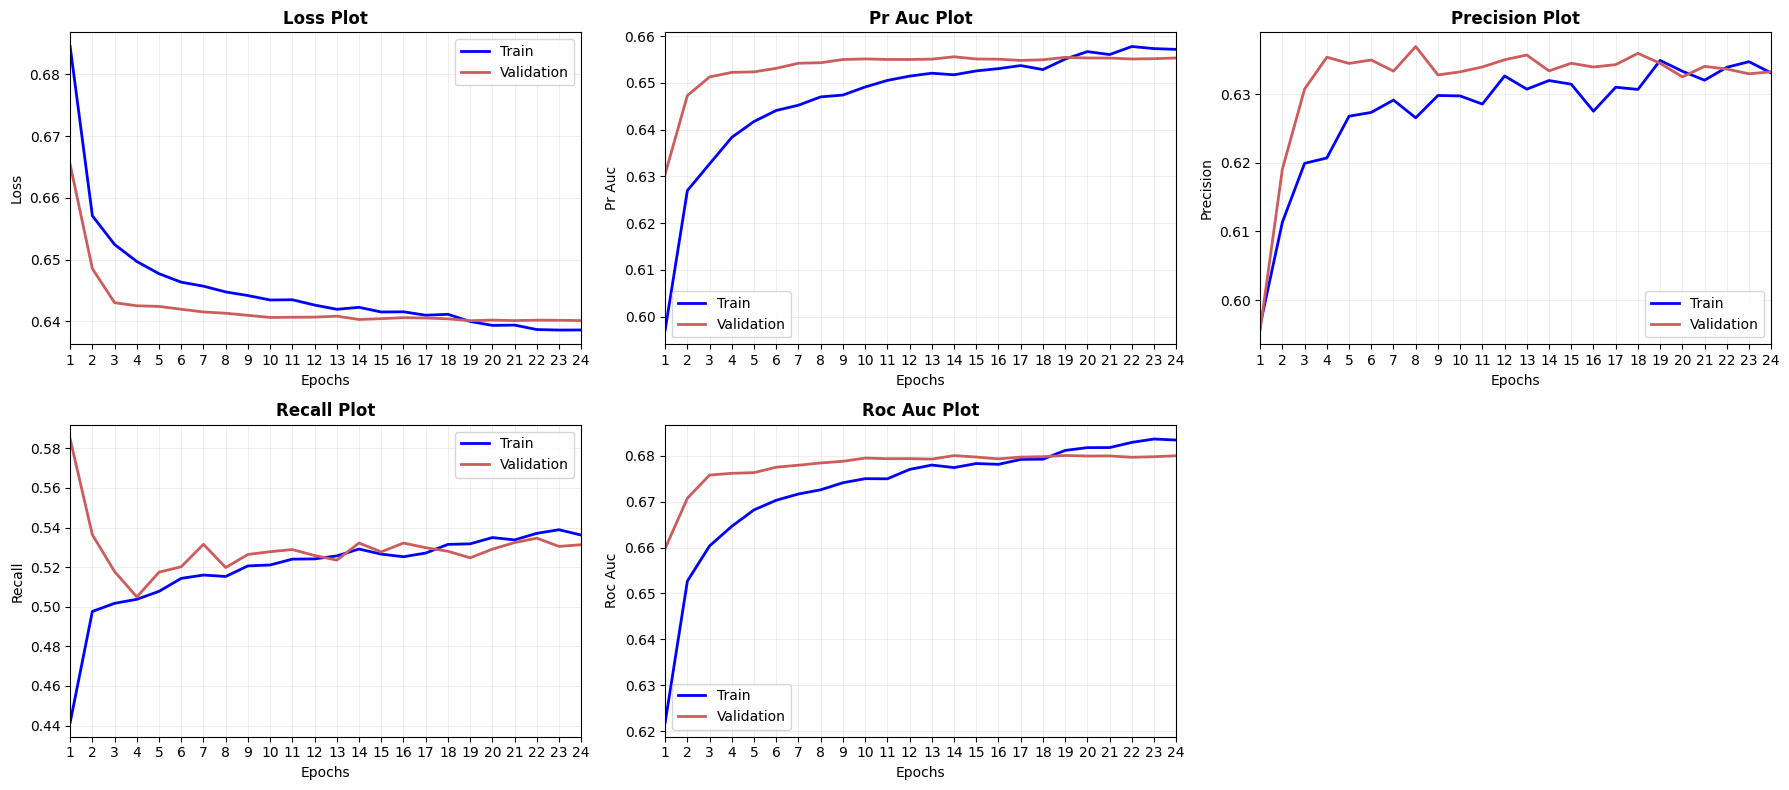

In [26]:
plot_model_report(history= init_history.history)

#### Part 3: Fine-tuning model of using Optuna

**3.1** Defining trainable-embedding model architecture to be optimised:


In [27]:
def build_model_optuna(trial):

    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    hidden_units = [
        trial.suggest_categorical(
            f'units_l{layer_idx + 1}',
            [32, 64, 128, 256]
        )
        for layer_idx in range(n_dense_layers)
    ]

    embedding_dim = trial.suggest_int('embedding_dim', 2, 8)
    kernel_regularizer = trial.suggest_float('kernel_regularizer', 1e-7, 1e-3, log=True)
    lr = trial.suggest_float('learning_rate', 1e-5, 3e-3, log= True)
    drt = trial.suggest_float('dropout_rate', 0.0, 0.4, step= 0.05)
    leaky_relu_alpha = trial.suggest_categorical('LeakyReLU_alpha', [0.05, 0.1, 0.2, 0.3])

    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= embedding_dim,
        hidden_units= hidden_units,
        kernel_regularizer= kernel_regularizer,
        lr=lr,
        dropout_rate= drt,
        leaky_relu_alpha= leaky_relu_alpha,
    )

    return model


**3.2** Defining fitting function (more hyper-parameters to be optimised):


In [28]:
def fit_model_optuna(trial, model, batch_size, positive_class_weight, epochs= 50, verbose=1):
    history = model.fit(
        train_inputs, y_train_array,
        validation_data=(val_inputs, y_val_array),
        epochs=epochs,
        batch_size=batch_size,
        class_weight={0: 1.0, 1: positive_class_weight},
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_pr_auc',
                mode='max',
                patience=8,
                restore_best_weights=True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_pr_auc',
                mode='max',
                factor= 0.5,
                patience= 3,
                min_lr= 1e-5
            ),
        ],
        verbose=verbose,
    )

    return history

**3.3** Defining the objective function. The study optimizes validation PR AUC directly.


In [29]:
def objective_fn(trial):
    """
    Defines the objective function for an Optuna optimization trial. The function configures the
    model and its parameters, evaluates its performance, and stores the best results for analysis.
    """
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    positive_class_weight = trial.suggest_float('positive_class_weight', 1.0, 1.4, step= 0.05)

    # build and fit the model
    model = build_model_optuna(trial)
    history = fit_model_optuna(
        trial,
        model,
        batch_size=batch_size,
        positive_class_weight=positive_class_weight,
    )

    # the objective is to maximize the validation PR-AUC
    val_pr_auc = history.history['val_pr_auc']
    best_epoch_idx = int(np.argmax(val_pr_auc))

    # set attributes for the Optuna trial
    trial.set_user_attr('best_epoch', best_epoch_idx + 1)
    trial.set_user_attr('best_val_pr_auc', float(history.history['val_pr_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_roc_auc', float(history.history['val_roc_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_recall', float(history.history['val_recall'][best_epoch_idx]))
    trial.set_user_attr('best_val_precision', float(history.history['val_precision'][best_epoch_idx]))

    return float(history.history['val_pr_auc'][best_epoch_idx])

**3.4** Running the optimization (study):

In [30]:
def extract_best_params(study):
    """
    Extract the best parameters from a completed Optuna study.
    """
    completed_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
    ]
    if not completed_trials:
        raise ValueError('No completed Optuna trials available. Run study.optimize first.')

    return study.best_params

In [31]:
# to load the existing study
# (saved under the model folder as a SQLite db format)
load_existing_study = True

###### ###### ######
storage_path = f"sqlite:///{export_dir / 'optuna_study.db'}"
num_trials = 40
sec_timeout = 3600


In [32]:
# create study (or load an existing one)
study = optuna.create_study(
    study_name='dnn_v2_selected_feats_optuna',
    direction='maximize',
    storage= storage_path,
    load_if_exists= True,
)

# checking if the study
# has already been completed
completed_trials = [
    trial for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

# Run optimization unless explicitly loading an existing study that already has results.
if (not load_existing_study) or (len(completed_trials) == 0):
    study.optimize( func= objective_fn,
                    n_trials= num_trials,
                    timeout= sec_timeout
                   )

[I 2026-07-16 12:01:56,671] Using an existing study with name 'dnn_v2_selected_feats_optuna' instead of creating a new one.


In [33]:
# extracting best parameters from the study
best_params = extract_best_params(study)
best_params

{'batch_size': 512,
 'positive_class_weight': 1.3,
 'n_dense_layers': 1,
 'units_l1': 256,
 'embedding_dim': 4,
 'kernel_regularizer': 0.0005261191500114241,
 'learning_rate': 0.0006848852006585244,
 'dropout_rate': 0.25,
 'LeakyReLU_alpha': 0.1}

**3.5** Creating the final fine-tuned model:

In [34]:
def build_model_fine_tuned(best_parameters= best_params,
                           fit_model= True,
                           epochs= 80,
                           verbose= 1):
    # setting the seed for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    n_dense_layers = best_parameters['n_dense_layers']
    hidden_units = [
        best_parameters[f'units_l{layer_idx + 1}']
        for layer_idx in range(n_dense_layers)
    ]

    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= best_parameters['embedding_dim'],
        hidden_units= hidden_units,
        kernel_regularizer= best_parameters['kernel_regularizer'],
        lr= best_parameters['learning_rate'],
        dropout_rate= best_parameters['dropout_rate'],
        leaky_relu_alpha= best_parameters['LeakyReLU_alpha'],
    )

    history = None
    if fit_model:
        history = model.fit(
            train_inputs, y_train_array,
            validation_data= (val_inputs, y_val_array),
            epochs= epochs,
            batch_size= best_parameters['batch_size'],
            class_weight= {0: 1.0, 1: best_parameters['positive_class_weight']},
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_pr_auc',
                    mode='max',
                    patience=10,
                    restore_best_weights=True
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor='val_pr_auc',
                    mode='max',
                    factor=0.5,
                    patience=4,
                    min_lr=1e-5
                ),
            ],
            verbose=verbose,
        )

    return model, history


**Getting the structure of the model without fitting it first**:

In [35]:
model_finetuned, _ = build_model_fine_tuned(
    best_parameters=best_params,
    fit_model= False,
    epochs= 80,
    verbose= 1
)
model_finetuned.summary()

Model: "dnn_v2_selected_features"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pipeline_raw__race  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1)         │          0 │ pipeline_raw__ra… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1)         │          0 │ pipeline_raw__ag… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ pipeline_admissi… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ pipeline_dischar… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ pipeline_medical… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1, 4)      │         28 │ pipeline_raw__ra… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1, 4)      │         44 │ pipeline_raw__ag… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1, 4)      │         20 │ pipeline_admissi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1, 4)      │         16 │ pipeline_dischar… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1, 4)      │         52 │ pipeline_medical… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 4)         │          0 │ pipeline_raw__ra

 Total params: 9,761 (38.13 KB)

 Trainable params: 9,185 (35.88 KB)

 Non-trainable params: 576 (2.25 KB)

**Fitting the fine-tuned model**:

In [36]:
model_finetuned, history_fine_tuned = build_model_fine_tuned(
    best_parameters= best_params,
    fit_model= True,
    epochs= 80,
    verbose=1
)


Epoch 1/80
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.0414 - pr_auc: 0.5826 - precision: 0.5442 - recall: 0.6224 - roc_auc: 0.6138 - val_loss: 0.8983 - val_pr_auc: 0.6182 - val_precision: 0.5500 - val_recall: 0.7138 - val_roc_auc: 0.6502 - learning_rate: 6.8489e-04
Epoch 2/80
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9682 - pr_auc: 0.6067 - precision: 0.5598 - recall: 0.6428 - roc_auc: 0.6380 - val_loss: 0.8475 - val_pr_auc: 0.6337 - val_precision: 0.5821 - val_recall: 0.6362 - val_roc_auc: 0.6606 - learning_rate: 6.8489e-04
Epoch 3/80
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9204 - pr_auc: 0.6203 - precision: 0.5648 - recall: 0.6528 - roc_auc: 0.6478 - val_loss: 0.8062 - val_pr_auc: 0.6439 - val_precision: 0.5941 - val_recall: 0.6048 - val_roc_auc: 0.6682 - learning_rate: 6.8489e-04
Epoch 4/80
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8837 - pr_auc: 0.6268 - precision: 0.5693 - recall: 0.6618 - roc_auc: 0.6555 - val_loss: 0.7749 - val_pr_auc: 0.647

**Plotting AUC, Recall and Loss of the fine-tuned model (train & validation set)**:

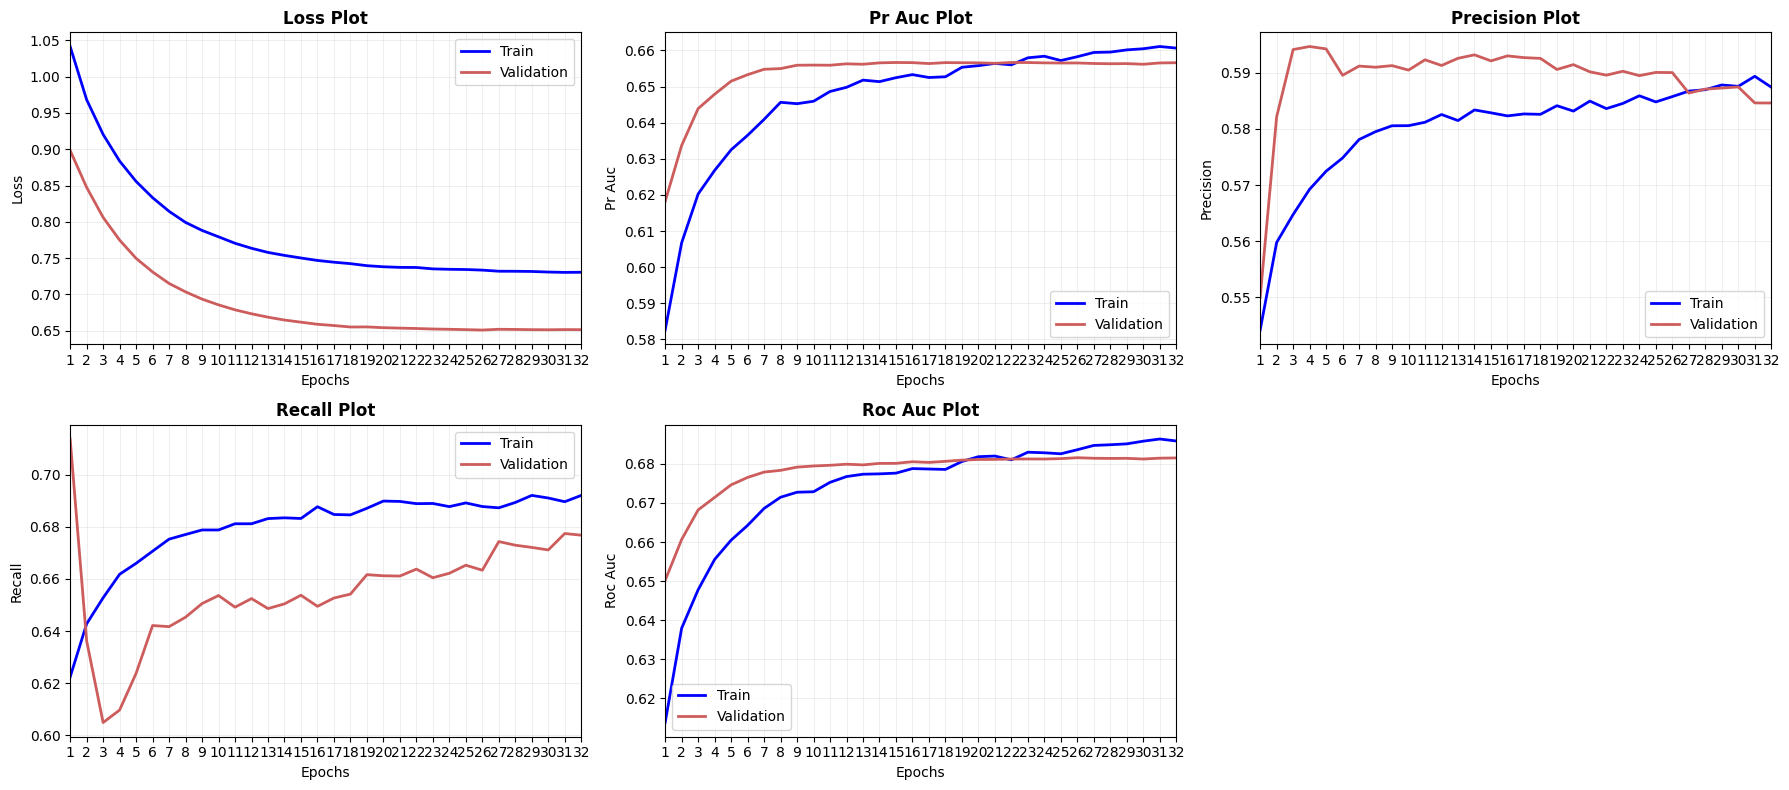

In [37]:
plot_model_report(history= history_fine_tuned.history)

### Part 4: Choosing a validation-set threshold and converting predictions to binary


In [38]:
def find_best_threshold(y_true, y_proba, metric='f1', min_precision=None):
    """
    Finds the optimal probability threshold for binary classification based on a given metric,
    while optionally enforcing a minimum precision constraint.

    Given the true binary labels and the predicted probabilities, this function evaluates various
    threshold values and calculates their corresponding performance metrics (precision, recall, F1-score,
    accuracy). It allows the user to specify whether the optimization should prioritize a particular metric,
    such as 'f1', 'recall', or 'precision'. Optionally, a minimum precision threshold can be enforced,
    which will exclude thresholds that do not satisfy the precision requirement.

    :param y_true: Array-like of shape (n_samples,) containing the ground-truth binary labels. Input data is
        expected to be in binary {0, 1} format.
    :param y_proba: Array-like of shape (n_samples,) containing the predicted probabilities for the positive
        class (class 1). Probabilities should be in the range [0.0, 1.0].
    :param metric: Optional string value specifying the performance metric to optimize. Default is 'f1'.
        Allowed values include 'f1', 'precision', and 'recall'.
    :param min_precision: Optional float value specifying the minimum precision constraint. If provided,
        thresholds that result in a precision below this value will be penalized by assigning a negative
        infinity score.

    :return: A tuple containing two elements:
        - Best threshold value (float) optimizing the specified metric.
        - A pandas DataFrame containing detailed performance metrics (threshold, precision, recall,
          F1-score, accuracy, and score) for all evaluated thresholds across the range [0.05, 0.95].
    """
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba).ravel()
    thresholds = np.linspace(0.05, 0.95, 181)

    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)

        if metric == 'recall':
            score = recall
        elif metric == 'precision':
            score = precision
        else:
            score = f1

        if min_precision is not None and precision < min_precision:
            score = -np.inf

        rows.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'score': score,
        })

    threshold_results = pd.DataFrame(rows)
    best_row = threshold_results.sort_values('score', ascending=False).iloc[0]

    return float(best_row['threshold']), threshold_results

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Best validation threshold: 0.365


,threshold,precision,recall,f1_score,accuracy,score
63,0.365,0.517564,0.904838,0.658480,0.557703,0.658480
65,0.375,0.521606,0.892129,0.658313,0.563592,0.658313
64,0.370,0.519129,0.898537,0.658062,0.559968,0.658062
62,0.360,0.515139,0.910392,0.657970,0.553979,0.657970
66,0.380,0.523599,0.885080,0.657960,0.566360,0.657960


              precision    recall  f1-score   support

           0       0.76      0.24      0.36     31515
           1       0.52      0.91      0.66     28090

    accuracy                           0.56     59605
   macro avg       0.64      0.58      0.51     59605
weighted avg       0.64      0.56      0.50     59605

              precision    recall  f1-score   support

           0       0.75      0.25      0.37     10506
           1       0.52      0.90      0.66      9363

    accuracy                           0.56     19869
   macro avg       0.63      0.58      0.52     19869
weighted avg       0.64      0.56      0.51     19869



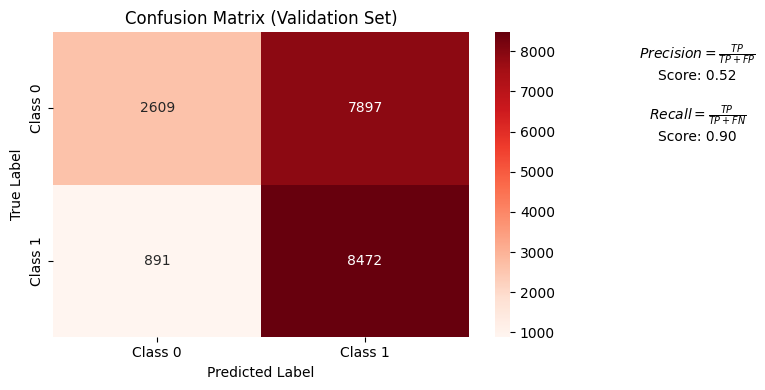

In [39]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

# Select threshold on validation set only.
best_threshold, threshold_results = find_best_threshold(
    y_true=y_val_array,
    y_proba=ypred_val_proba,
    metric='f1'
)

print(f'Best validation threshold: {best_threshold:.3f}')
display(threshold_results.sort_values('score', ascending=False).head())

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= best_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= best_threshold).astype(int).flatten()

# Now evaluate using your evaluation function
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values=y_train,
                         predictions=ypred_train_binary,
                         print_class_report=True)

recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values=y_val,
                         predictions=ypred_val_binary,
                         print_class_report=True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true=y_val['readmitted'],
                               y_pred=ypred_val_binary,
                               fig_size=(8, 4),
                               title='Confusion Matrix (Validation Set)',
                               colour_map='Reds')


### Part 5: Test Set Evaluation

Generating predictions on test data...
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test set size: 19869 samples
Predictions generated: 19869
Classification threshold: 0.365

              precision    recall  f1-score   support

           0       0.74      0.25      0.37     10506
           1       0.52      0.91      0.66      9363

    accuracy                           0.56     19869
   macro avg       0.63      0.58      0.51     19869
weighted avg       0.64      0.56      0.51     19869



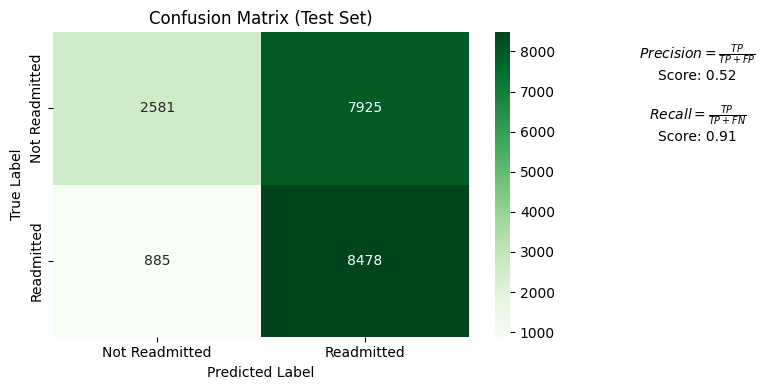

In [40]:
# Generate predictions on test set
print('Generating predictions on test data...')
ypred_test_proba = model_finetuned.predict(test_inputs).ravel()

# Convert to binary predictions using the validation-selected threshold.
ypred_test_binary = (ypred_test_proba >= best_threshold).astype(int).flatten()

print(f'Test set size: {len(y_test)} samples')
print(f'Predictions generated: {len(ypred_test_binary)}')
print(f'Classification threshold: {best_threshold:.3f}')
print()

# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions=ypred_test_binary,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred=ypred_test_binary,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set)',
                                    colour_map='Greens')


In [41]:
# Summarising evaluation metrics
print()
print('-' * 30)
print('TEST SET PERFORMANCE SUMMARY')
print('-' * 30)
print(f'Threshold: {best_threshold:.3f}')
print(f'Accuracy:  {acc_test:.4f}')
print(f'Recall:    {recall_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'F1-Score:  {f1_test:.4f}')
print('-' * 30)
print()

# storing results for comparison
test_results = {
    'dataset': 'test',
    'n_samples': len(y_test),
    'threshold': best_threshold,
    'accuracy': acc_test,
    'recall': recall_test,
    'precision': precision_test,
    'f1_score': f1_test,
    'confusion_matrix': scores_test['confusion_matrix']
}



------------------------------
TEST SET PERFORMANCE SUMMARY
------------------------------
Threshold: 0.365
Accuracy:  0.5566
Recall:    0.9055
Precision: 0.5169
F1-Score:  0.6581
------------------------------



In [42]:
test_results

{'dataset': 'test',
 'n_samples': 19869,
 'threshold': 0.36499999999999994,
 'accuracy': 0.5565957018470985,
 'recall': 0.9054790131368151,
 'precision': 0.5168566725598975,
 'f1_score': 0.6580765349685632,
 'confusion_matrix': array([[2581, 7925],
        [ 885, 8478]])}

**Saving the model:**

In [43]:
MODEL_PATH = export_dir / "dnnv2_vts_finetuned.keras"
model_finetuned.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH.resolve()}")

Model saved to: /Users/vassilistsoubris/PycharmProjects/ds207_final_project/models/dnn_v2_sel_feats/dnnv2_vts_finetuned.keras
